In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

In [3]:
df = pd.read_csv("../data/raw/loan_data.csv")

In [4]:
X = df.drop(columns=["loan_status"])
y = df["loan_status"]

In [5]:
X["loan_to_income"] = (
    X["loan_amnt"] / X["person_income"]
)

In [6]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [9]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [11]:
nb_model = GaussianNB()

In [12]:
nb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            nb_model
        )
    ]
)

In [13]:
nb_pipeline.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
y_pred_nb = nb_pipeline.predict(X_test)

In [15]:
y_prob_nb = nb_pipeline.predict_proba(
    X_test
)[:, 1]

In [16]:
nb_accuracy = accuracy_score(
    y_test,
    y_pred_nb
)

nb_precision = precision_score(
    y_test,
    y_pred_nb
)

nb_recall = recall_score(
    y_test,
    y_pred_nb
)

nb_f1 = f1_score(
    y_test,
    y_pred_nb
)

nb_roc_auc = roc_auc_score(
    y_test,
    y_prob_nb
)

In [17]:
print("Gaussian Naive Bayes")
print("-" * 30)

print(f"Accuracy : {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall   : {nb_recall:.4f}")
print(f"F1 Score : {nb_f1:.4f}")
print(f"ROC-AUC  : {nb_roc_auc:.4f}")

Gaussian Naive Bayes
------------------------------
Accuracy : 0.7364
Precision: 0.4574
Recall   : 0.9990
F1 Score : 0.6275
ROC-AUC  : 0.9405


In [18]:
print(
    classification_report(
        y_test,
        y_pred_nb
    )
)

              precision    recall  f1-score   support

           0       1.00      0.66      0.80      7000
           1       0.46      1.00      0.63      2000

    accuracy                           0.74      9000
   macro avg       0.73      0.83      0.71      9000
weighted avg       0.88      0.74      0.76      9000



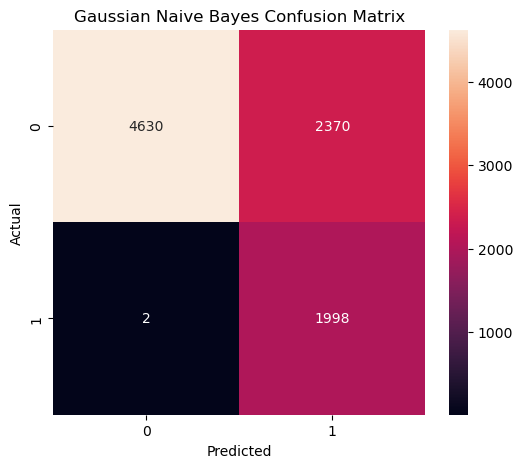

In [19]:
cm_nb = confusion_matrix(
    y_test,
    y_pred_nb
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Gaussian Naive Bayes Confusion Matrix")

plt.show()

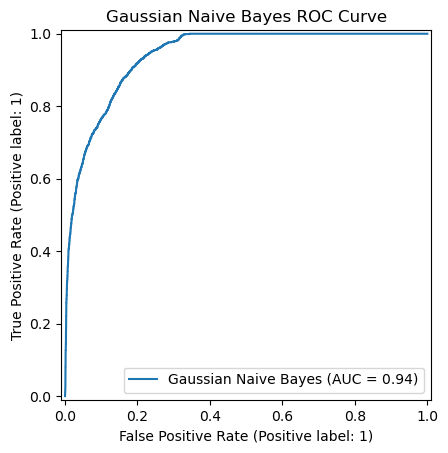

In [20]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_nb,
    name="Gaussian Naive Bayes"
)

plt.title("Gaussian Naive Bayes ROC Curve")
plt.show()

In [21]:
import joblib

In [22]:
joblib.dump(
    nb_pipeline,
    "../models/gaussian_nb_pipeline.joblib"
)

['../models/gaussian_nb_pipeline.joblib']